In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import japanize_matplotlib

In [2]:
df = pd.read_csv("../data/marketing_AB.csv", index_col=0)

df["group_idx"] = df["test group"].map({"psa": 0, "ad": 1})
df["log_ads"] = np.log1p(df["total ads"])

log_ads_std = (df["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()



In [3]:
#サブサンプリングで実施
df_sub = df.sample(frac=0.15, random_state=42)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_sub["day_idx"] = pd.Categorical(df_sub["most ads day"], categories=day_order).codes

n_days = len(day_order)

df_sub["hour_idx"] = df_sub["most ads hour"].astype(int)
n_hours = 24

day_idx_sub = df_sub["day_idx"].values
hour_idx_sub = df_sub["hour_idx"].values
log_ads_std_sub = (df_sub["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
converted_sub = df_sub["converted"].astype(int).values
group_idx_sub = df_sub["group_idx"].values

with pm.Model() as model_hier_sub:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta2 = pm.Normal("beta2", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)

    sigma_day = pm.HalfNormal("sigma_day", sigma=0.5)
    day_offset_raw = pm.Normal("day_offset_raw", sigma=0.5, shape=n_days)
    day_effect = pm.Deterministic("day_effect", sigma_day * day_offset_raw)

    sigma_hour = pm.HalfNormal("sigma_hour", sigma=0.5)
    hour_offset_raw = pm.Normal("hour_offset_raw", sigma=0.5, shape=n_hours)
    hour_effect = pm.Deterministic("hour_effect", sigma_hour * hour_offset_raw)
    

    logit_p = (
        beta0
        + day_effect[day_idx_sub]
        + hour_effect[hour_idx_sub]
        + beta1 * group_idx_sub
        + beta2 * log_ads_std_sub
        + beta3 * group_idx_sub * log_ads_std_sub
    )

    p = pm.Deterministic("p", pm.math.invlogit(logit_p))
    obs = pm.Bernoulli("obs", p=p, observed=converted_sub)

df_sub.to_csv("../data/df_sub_cross_random_effect.csv")
    

/tmp/ipykernel_3342/3374326411.py:19: DeprecationWarning: `pymc.logit` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.math.logit` instead.
  beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)


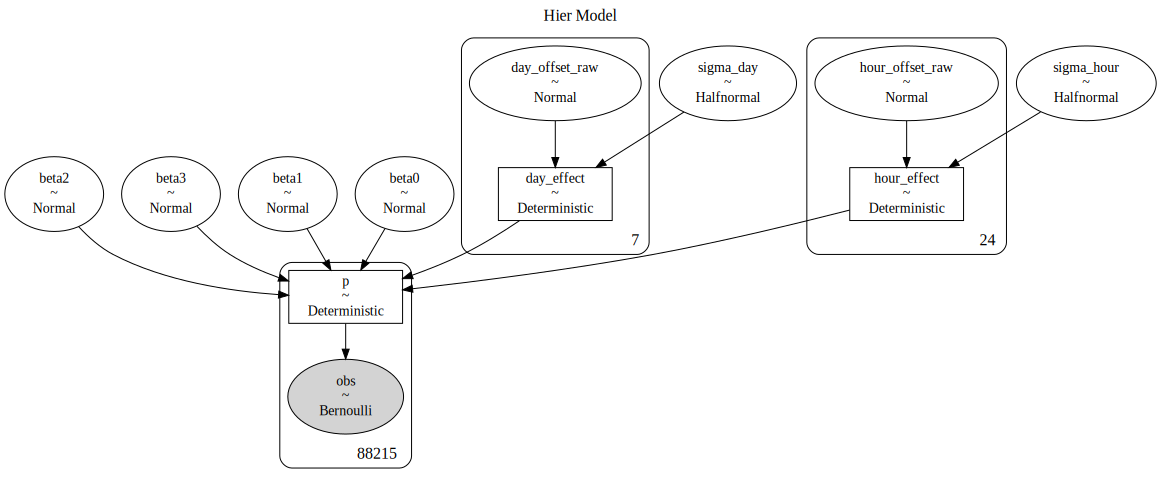

In [4]:
g = pm.model_to_graphviz(model_hier_sub)
g.graph_attr.update(
    label="Hier Model",
    labelloc="t",
    fontsize="16"
)
g.render(filename="../models/model_hier", format="png", cleanup=True)
g

In [5]:
with model_hier_sub:
    prior_pred = pm.sample_prior_predictive(draws=500)

Sampling: [beta0, beta1, beta2, beta3, day_offset_raw, hour_offset_raw, obs, sigma_day, sigma_hour]


In [6]:
p_pred = prior_pred.prior["p"].values.flatten()
print(f"pの最小値: {p_pred.min()}, pの平均値:{p_pred.mean()}, pの最大値:{p_pred.max()}")
print(f"pの95%範囲:{np.percentile(p_pred, 2.5)}~{np.percentile(p_pred, 97.5)}")

pの最小値: 3.4475392029633404e-05, pの平均値:0.04935232323768166, pの最大値:0.9822700686040147
pの95%範囲:0.0027362322720254524~0.21954100069536642


In [7]:
with model_hier_sub:
    trace_hier = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=4,
        nuts_sampler="numpyro",
        target_accept=0.9,
        random_seed=42
    )

NUTS[numpyro]: [beta0, beta1, beta2, beta3, sigma_day, day_offset_raw, sigma_hour, hour_offset_raw]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%|                                                                             | 0/2000 [00:00<?, ?it/s]

  0%|                                                                                           | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                             | 0/2000 [00:00<?, ?it/s]


  0%|                                                                                           | 0/2000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                          | 0/2000 [00:02<?, ?it/s]

Running chain 2:   0%|                                                                          | 0/2000 [00:02<?, ?it/s]


Running chain 3:   0%|                          

In [8]:
print(f"divergence:{trace_hier.sample_stats.diverging.sum().item()}")
az.summary(trace_hier, var_names=["beta0", "beta1", "beta2", "beta3", "sigma_day", "sigma_hour"])

divergence:0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-4.6,0.184,-4.9,-4.3,1335,1628,1.00,0.005,0.0037
beta1,-0.046,0.147,-0.28,0.19,2280,2762,1.00,0.0031,0.0022
beta2,1.04,0.103,0.87,1.2,1898,2209,1.00,0.0024,0.0017
beta3,0.375,0.105,0.21,0.54,1925,2465,1.00,0.0024,0.0017
sigma_day,0.492,0.15,0.3,0.77,1539,2173,1.00,0.0037,0.0039
sigma_hour,0.595,0.137,0.4,0.83,1059,1611,1.00,0.0041,0.0032


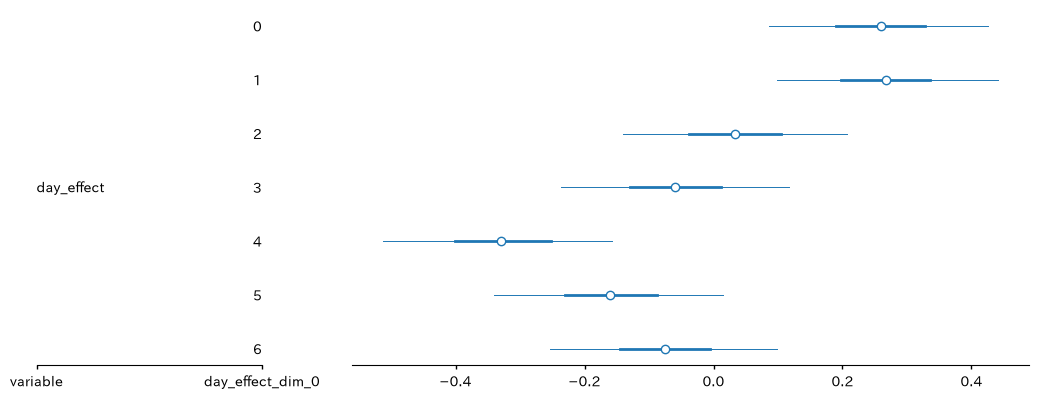

In [9]:
az.plot_forest(trace_hier, var_names=["day_effect"], combined=True)

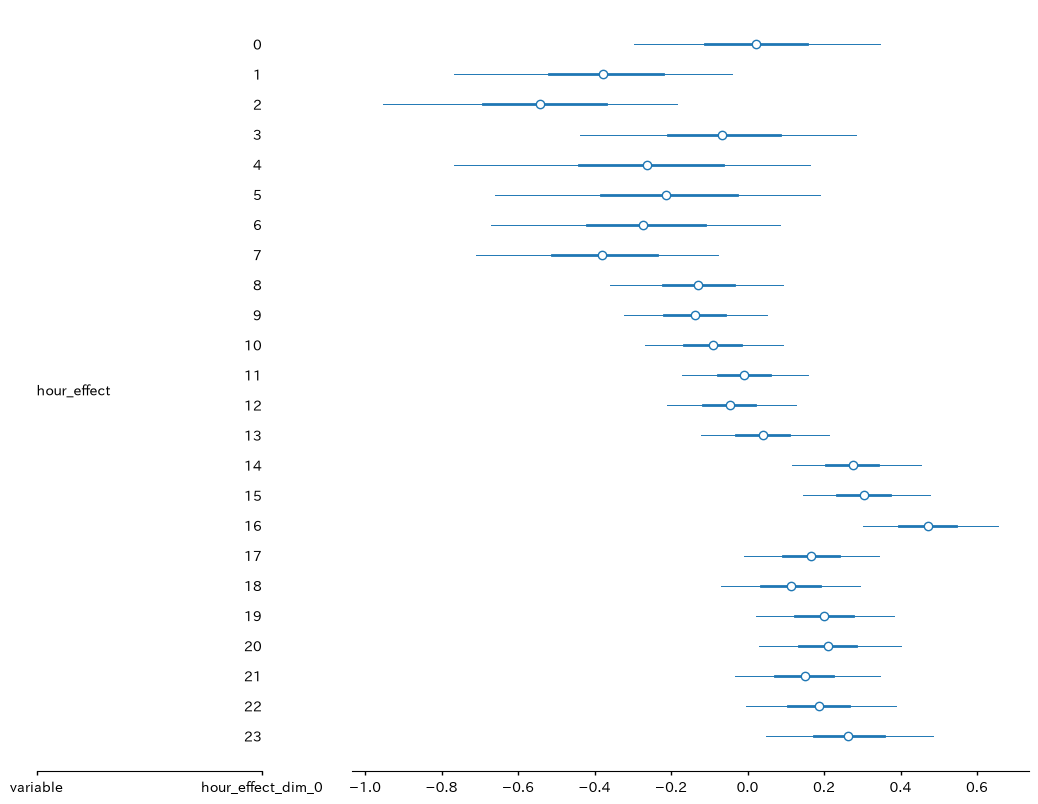

In [10]:
az.plot_forest(trace_hier, var_names=["hour_effect"], combined=True)

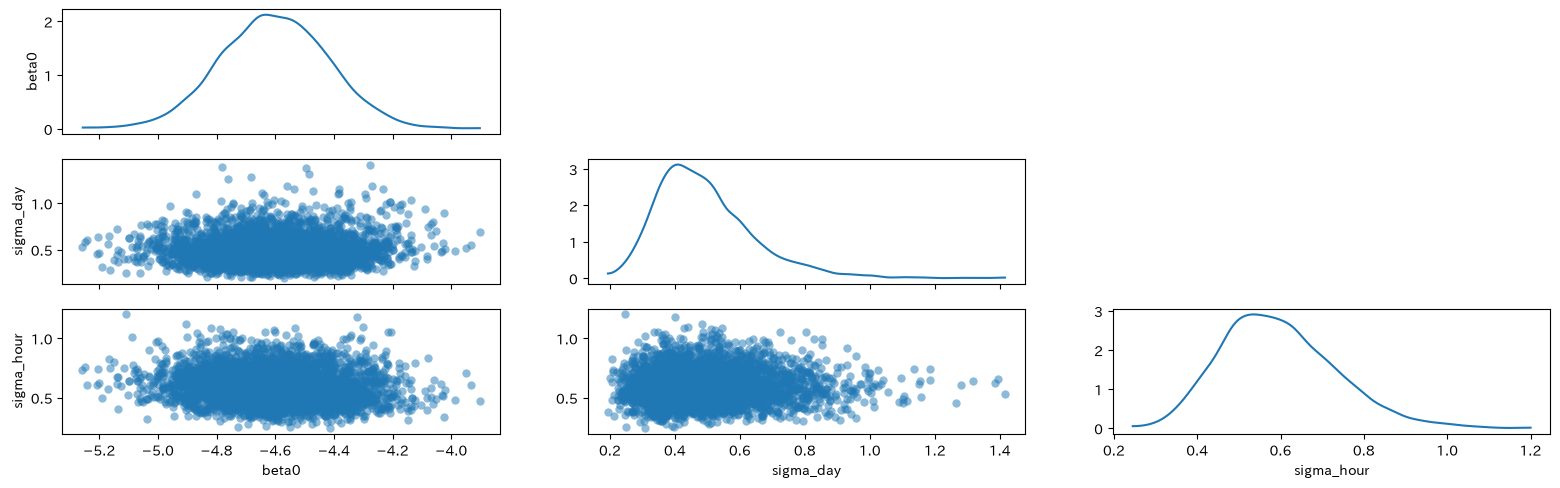

In [11]:
az.plot_pair(trace_hier, var_names=["beta0", "sigma_day", "sigma_hour"])

In [12]:
with model_hier_sub:
    pm.compute_log_likelihood(trace_hier)

trace_hier.to_netcdf("../models/trace_hier.nc")

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')